# LOSO CV: Seasonal Interaction Kernel (AOT × Season + SmogI/SmogP × Season)

This notebook encodes the hypothesis that **AOT drives PM2.5 in summer** (wildfire smoke)
while **smogI and smogP drive PM2.5 in winter** (cold air drainage / inversions).

## Kernel structure
```
k = ScaleKernel(RBF_ARD(base_features))              # shared: static + general meteorology
  + ScaleKernel(RBF(aot) × LocallyPeriodic(doy))     # AOT effect, seasonally modulated
  + ScaleKernel(RBF(smogI,smogP) × LocallyPeriodic(doy))  # inversion effect, seasonally modulated
  + ScaleKernel(LocallyPeriodic(doy))                 # residual seasonality
```

Where `LocallyPeriodic = PeriodicKernel × RBF` on day_of_year.

The product kernels gate each feature group by season — the GP learns *when* each
feature's influence is active. The scale kernels learn the relative importance of
each component.

**Batch size:** 10000

In [1]:
import sys
sys.path.insert(0, '../..')
import pandas as pd
import numpy as np
import torch
import gpytorch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

from timing_utils import TimingLogger, Timer

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

timing_log = TimingLogger("../../timings/gpr_timings.csv", experiment_name="seasonal_interaction_loso")
print("Timing logger initialized")

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Timing logger initialized


## 1. Load and Prepare Data

In [2]:
# Load datasets
pm_all = pd.read_csv("../../../data/pm25_data_complete_2003_2021_smogI_031026.csv", low_memory=False)
pm_fixed = pd.read_csv('../../../eda/pm25_locs_with_states.csv')

# Filter to Montana
mt_sites = pm_fixed[pm_fixed['state'] == 'MT'].copy()
mt_ll_ids = set(mt_sites['ll_id'].values)

# Parse date and filter to 2018-2019
pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')
pm_all['year'] = pm_all['date'].dt.year
pm_mt = pm_all[(pm_all['ll_id'].isin(mt_ll_ids)) & (pm_all['year'].isin([2018, 2019]))].copy()

print(f"Montana 2018-2019: {len(pm_mt):,} observations from {pm_mt['ll_id'].nunique()} sites")

Montana 2018-2019: 15,572 observations from 32 sites


In [3]:
# Define features
time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k',
                   'heavy_industrial_ind1', 'housing']

available_tv = [f for f in time_varying_features if f in pm_mt.columns]
available_static = [f for f in static_features if f in mt_sites.columns]

# Merge datasets
pm_mt_subset = pm_mt[['ll_id', 'date', 'pm25'] + available_tv].copy()
mt_static = mt_sites[['ll_id'] + available_static].copy()
df = pm_mt_subset.merge(mt_static, on='ll_id', how='left')

# Add day_of_year for periodic kernels
df['day_of_year'] = df['date'].dt.dayofyear

# Feature columns: weather + static + temporal
feature_cols = available_tv + available_static + ['day_of_year']

# Compute feature indices for kernel components
aot_idx = feature_cols.index('aot')
smogI_idx = feature_cols.index('smogI')
smogP_idx = feature_cols.index('smogP')
doy_idx = feature_cols.index('day_of_year')

# Base features: everything except aot, smogI, smogP, day_of_year
# (those are handled by their own kernel components)
seasonal_interaction_features = {'aot', 'smogI', 'smogP', 'day_of_year'}
base_indices = [i for i, f in enumerate(feature_cols) if f not in seasonal_interaction_features]
base_feature_names = [feature_cols[i] for i in base_indices]

# Clean data
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()

print(f"Clean data: {len(df_clean):,} observations")
print(f"\nAll features ({len(feature_cols)}): {feature_cols}")
print(f"\nBase features ({len(base_indices)}): {base_feature_names}")
print(f"  indices: {base_indices}")
print(f"\nSeasonal interaction features:")
print(f"  AOT (summer):       index {aot_idx}")
print(f"  smogI (winter):     index {smogI_idx}")
print(f"  smogP (winter):     index {smogP_idx}")
print(f"  day_of_year:        index {doy_idx}")

Clean data: 15,572 observations

All features (17): ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing', 'day_of_year']

Base features (13): ['wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']
  indices: [1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15]

Seasonal interaction features:
  AOT (summer):       index 0
  smogI (winter):     index 7
  smogP (winter):     index 8
  day_of_year:        index 16


In [4]:
# Check observations per site
site_counts = df_clean.groupby('ll_id').size().sort_values(ascending=False)
print(f"Observations per site:")
print(f"  Min: {site_counts.min()}, Max: {site_counts.max()}")
print(f"  Mean: {site_counts.mean():.1f}, Median: {site_counts.median():.1f}")
print(f"\nday_of_year range: {df_clean['day_of_year'].min()} - {df_clean['day_of_year'].max()}")
print(f"day_of_year std: {df_clean['day_of_year'].std():.1f}")
print(f"Expected period in standardized units: {365.25 / df_clean['day_of_year'].std():.2f}")

Observations per site:
  Min: 6, Max: 730
  Mean: 486.6, Median: 705.5

day_of_year range: 1 - 365
day_of_year std: 104.8
Expected period in standardized units: 3.49


## 2. Define Seasonal Interaction GP Model

In [5]:
class SeasonalInteractionGP(gpytorch.models.ExactGP):
    """GP with seasonal interaction kernels.

    Kernel = ScaleKernel(RBF_ARD(base_features))
           + ScaleKernel(RBF(aot) x Periodic(doy) x RBF(doy))       # AOT x season
           + ScaleKernel(RBF(smogI,smogP) x Periodic(doy) x RBF(doy))  # inversion x season
           + ScaleKernel(Periodic(doy) x RBF(doy))                   # residual seasonality

    The product kernels encode that AOT matters more in one part of the year
    and smogI/smogP matter more in another. The GP learns the phasing from data.
    """

    def __init__(self, train_x, train_y, likelihood,
                 base_indices, aot_idx, smogI_idx, smogP_idx, doy_idx,
                 period_init=None):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()

        # --- Component 1: Base RBF with ARD on non-interaction features ---
        self.base_kernel = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                ard_num_dims=len(base_indices),
                active_dims=torch.tensor(base_indices)
            )
        )

        # --- Component 2: AOT x LocallyPeriodic(doy) — summer driver ---
        self.aot_rbf = gpytorch.kernels.RBFKernel(
            active_dims=torch.tensor([aot_idx])
        )
        self.aot_periodic = gpytorch.kernels.PeriodicKernel(
            active_dims=torch.tensor([doy_idx])
        )
        self.aot_seasonal_rbf = gpytorch.kernels.RBFKernel(
            active_dims=torch.tensor([doy_idx])
        )
        if period_init is not None:
            self.aot_periodic.initialize(period_length=period_init)
        self.summer_kernel = gpytorch.kernels.ScaleKernel(
            self.aot_rbf * self.aot_periodic * self.aot_seasonal_rbf
        )

        # --- Component 3: (smogI, smogP) x LocallyPeriodic(doy) — winter driver ---
        self.smog_rbf = gpytorch.kernels.RBFKernel(
            ard_num_dims=2,
            active_dims=torch.tensor([smogI_idx, smogP_idx])
        )
        self.smog_periodic = gpytorch.kernels.PeriodicKernel(
            active_dims=torch.tensor([doy_idx])
        )
        self.smog_seasonal_rbf = gpytorch.kernels.RBFKernel(
            active_dims=torch.tensor([doy_idx])
        )
        if period_init is not None:
            self.smog_periodic.initialize(period_length=period_init)
        self.winter_kernel = gpytorch.kernels.ScaleKernel(
            self.smog_rbf * self.smog_periodic * self.smog_seasonal_rbf
        )

        # --- Component 4: Residual LocallyPeriodic(doy) ---
        self.residual_periodic = gpytorch.kernels.PeriodicKernel(
            active_dims=torch.tensor([doy_idx])
        )
        self.residual_seasonal_rbf = gpytorch.kernels.RBFKernel(
            active_dims=torch.tensor([doy_idx])
        )
        if period_init is not None:
            self.residual_periodic.initialize(period_length=period_init)
        self.seasonal_kernel = gpytorch.kernels.ScaleKernel(
            self.residual_periodic * self.residual_seasonal_rbf
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = (self.base_kernel(x)
                   + self.summer_kernel(x)
                   + self.winter_kernel(x)
                   + self.seasonal_kernel(x))
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [6]:
def train_gp(train_x, train_y, base_indices, aot_idx, smogI_idx, smogP_idx,
             doy_idx, period_init, n_epochs=50, lr=0.1, verbose=False):
    """Train seasonal interaction GP. Returns model, likelihood, and loss history."""
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = SeasonalInteractionGP(
        train_x, train_y, likelihood,
        base_indices, aot_idx, smogI_idx, smogP_idx, doy_idx,
        period_init
    ).to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    for i in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if verbose and (i + 1) % 20 == 0:
            print(f"  Epoch {i+1}, Loss: {loss.item():.4f}")

    return model, likelihood, losses


def predict_gp(model, likelihood, test_x):
    """Make predictions with a trained GP."""
    model.eval()
    likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(test_x))
        return pred.mean.cpu().numpy(), pred.variance.cpu().numpy()

## 3. Run LOSO Cross-Validation

In [7]:
MAX_TRAIN_SIZE = 10000
N_EPOCHS = 50

sites = df_clean['ll_id'].unique()
n_sites = len(sites)
print(f"Running LOSO CV across {n_sites} sites...")
print(f"MAX_TRAIN_SIZE = {MAX_TRAIN_SIZE}, N_EPOCHS = {N_EPOCHS}")

Running LOSO CV across 32 sites...
MAX_TRAIN_SIZE = 10000, N_EPOCHS = 50


In [8]:
# Storage for results
all_predictions = []
all_actuals = []
all_variances = []
site_metrics = []
fold_timings = []
learned_params = []  # Track learned kernel parameters
fold_losses = {}  # Track training losses per fold

cv_start = time.perf_counter()

for i, held_out_site in enumerate(tqdm(sites, desc="LOSO CV")):
    fold_start = time.perf_counter()

    # Split data
    test_mask = df_clean['ll_id'] == held_out_site
    train_df = df_clean[~test_mask]
    test_df = df_clean[test_mask]

    if len(test_df) == 0:
        continue

    # Extract features and target
    X_train = train_df[feature_cols].values
    y_train = np.log(train_df['pm25'].values + 1)
    X_test = test_df[feature_cols].values
    y_test = np.log(test_df['pm25'].values + 1)

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Period init in standardized units
    period_init = 365.25 / scaler.scale_[doy_idx]

    # Subsample training data if needed
    n_train_actual = len(X_train_scaled)
    if len(X_train_scaled) > MAX_TRAIN_SIZE:
        idx = np.random.choice(len(X_train_scaled), MAX_TRAIN_SIZE, replace=False)
        X_train_scaled = X_train_scaled[idx]
        y_train = y_train[idx]
        n_train_actual = MAX_TRAIN_SIZE

    # Convert to tensors
    train_x = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    train_y = torch.tensor(y_train, dtype=torch.float32).to(device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    # Train
    train_start = time.perf_counter()
    model, likelihood, losses = train_gp(
        train_x, train_y, base_indices, aot_idx, smogI_idx, smogP_idx,
        doy_idx, period_init, N_EPOCHS
    )
    train_time = time.perf_counter() - train_start
    fold_losses[held_out_site] = losses

    # Predict
    infer_start = time.perf_counter()
    pred_mean, pred_var = predict_gp(model, likelihood, test_x)
    infer_time = time.perf_counter() - infer_start

    fold_time = time.perf_counter() - fold_start

    # Record learned kernel parameters
    learned_params.append({
        'fold': i,
        'site': held_out_site,
        'base_scale': model.base_kernel.outputscale.item(),
        'summer_scale': model.summer_kernel.outputscale.item(),
        'winter_scale': model.winter_kernel.outputscale.item(),
        'seasonal_scale': model.seasonal_kernel.outputscale.item(),
        'aot_period_days': model.aot_periodic.period_length.item() * scaler.scale_[doy_idx],
        'smog_period_days': model.smog_periodic.period_length.item() * scaler.scale_[doy_idx],
        'residual_period_days': model.residual_periodic.period_length.item() * scaler.scale_[doy_idx],
        'noise': likelihood.noise.item(),
    })

    # Store predictions
    all_predictions.extend(pred_mean)
    all_actuals.extend(y_test)
    all_variances.extend(pred_var)

    # Site-level metrics
    site_rmse = np.sqrt(np.mean((pred_mean - y_test)**2))
    site_mae = np.mean(np.abs(pred_mean - y_test))
    ss_res = np.sum((y_test - pred_mean)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    site_r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

    site_metrics.append({
        'site': held_out_site,
        'n_obs': len(test_df),
        'rmse_log': site_rmse,
        'mae_log': site_mae,
        'r2_log': site_r2
    })

    fold_timings.append({
        'fold': i,
        'site': held_out_site,
        'n_train': n_train_actual,
        'n_test': len(test_df),
        'train_time': train_time,
        'infer_time': infer_time,
        'fold_time': fold_time
    })

    del model, likelihood
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

cv_total_time = time.perf_counter() - cv_start

timing_log.log("seasonal_interaction_loso_total", cv_total_time, years="2018-2019",
               n_folds=n_sites, n_features=len(feature_cols), n_epochs=N_EPOCHS,
               kernel="RBF_ARD+AOTxSeason+SmogxSeason+Seasonal")

print(f"\nLOSO CV complete!")
print(f"Total CV time: {cv_total_time:.1f}s ({cv_total_time/60:.1f} min)")

LOSO CV:   0%|          | 0/32 [00:00<?, ?it/s]

LOSO CV:   3%|▎         | 1/32 [00:18<09:20, 18.07s/it]

LOSO CV:   6%|▋         | 2/32 [00:34<08:39, 17.32s/it]

LOSO CV:   9%|▉         | 3/32 [00:51<08:15, 17.08s/it]

LOSO CV:  12%|█▎        | 4/32 [01:08<07:52, 16.88s/it]

...

LOSO CV:  94%|█████████▍| 30/32 [08:22<00:33, 16.72s/it]

LOSO CV:  97%|█████████▋| 31/32 [08:39<00:16, 16.71s/it]

LOSO CV: 100%|██████████| 32/32 [08:55<00:00, 16.67s/it]

LOSO CV: 100%|██████████| 32/32 [08:55<00:00, 16.74s/it]


LOSO CV complete!
Total CV time: 535.8s (8.9 min)


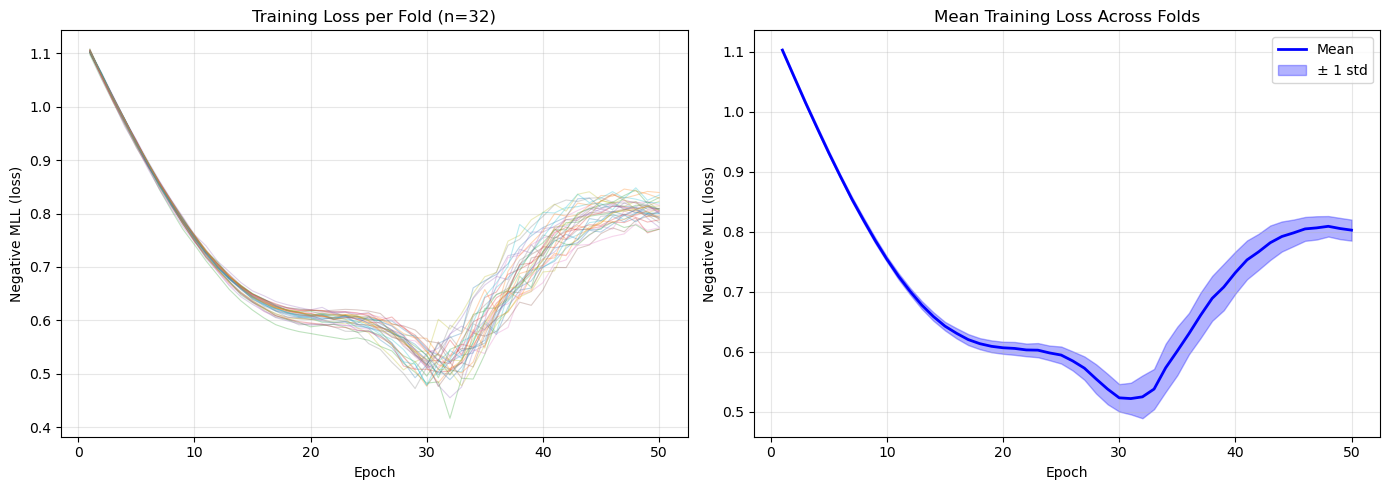

Final mean loss: 0.8029 ± 0.0175
Loss reduction: 1.1031 → 0.8029 (27.2%)


In [9]:
# Training loss vs epoch for all folds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual fold loss curves
for site, losses in fold_losses.items():
    axes[0].plot(range(1, len(losses) + 1), losses, alpha=0.3, linewidth=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative MLL (loss)')
axes[0].set_title(f'Training Loss per Fold (n={len(fold_losses)})')
axes[0].grid(True, alpha=0.3)

# Mean +/- std loss curve
loss_array = np.array(list(fold_losses.values()))
mean_loss = loss_array.mean(axis=0)
std_loss = loss_array.std(axis=0)
epochs = np.arange(1, len(mean_loss) + 1)
axes[1].plot(epochs, mean_loss, 'b-', linewidth=2, label='Mean')
axes[1].fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                     alpha=0.3, color='blue', label='± 1 std')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Negative MLL (loss)')
axes[1].set_title('Mean Training Loss Across Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final mean loss: {mean_loss[-1]:.4f} ± {std_loss[-1]:.4f}")
print(f"Loss reduction: {mean_loss[0]:.4f} → {mean_loss[-1]:.4f} ({(mean_loss[0]-mean_loss[-1])/abs(mean_loss[0])*100:.1f}%)")

## 4. Aggregate Results

In [10]:
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)
all_variances = np.array(all_variances)

# Log scale metrics
rmse_log = np.sqrt(np.mean((all_predictions - all_actuals)**2))
mae_log = np.mean(np.abs(all_predictions - all_actuals))
ss_res = np.sum((all_actuals - all_predictions)**2)
ss_tot = np.sum((all_actuals - np.mean(all_actuals))**2)
r2_log = 1 - (ss_res / ss_tot)

print("=" * 60)
print("LOSO CV Results (Seasonal Interaction Kernel) - Log Scale")
print("=" * 60)
print(f"Total predictions: {len(all_predictions):,}")
print(f"RMSE: {rmse_log:.4f}")
print(f"MAE:  {mae_log:.4f}")
print(f"R\u00b2:   {r2_log:.4f}")

LOSO CV Results (Seasonal Interaction Kernel) - Log Scale
Total predictions: 15,572
RMSE: 0.6937
MAE:  0.5314
R²:   0.1280


In [11]:
# Original scale
pred_pm25 = np.exp(all_predictions) - 1
actual_pm25 = np.exp(all_actuals) - 1

rmse_orig = np.sqrt(np.mean((pred_pm25 - actual_pm25)**2))
mae_orig = np.mean(np.abs(pred_pm25 - actual_pm25))
ss_res_orig = np.sum((actual_pm25 - pred_pm25)**2)
ss_tot_orig = np.sum((actual_pm25 - np.mean(actual_pm25))**2)
r2_orig = 1 - (ss_res_orig / ss_tot_orig)

print("\n" + "=" * 60)
print("LOSO CV Results (Seasonal Interaction Kernel) - Original Scale")
print("=" * 60)
print(f"RMSE: {rmse_orig:.2f} \u03bcg/m\u00b3")
print(f"MAE:  {mae_orig:.2f} \u03bcg/m\u00b3")
print(f"R\u00b2:   {r2_orig:.4f}")


LOSO CV Results (Seasonal Interaction Kernel) - Original Scale
RMSE: 6.28 μg/m³
MAE:  3.85 μg/m³
R²:   0.1520


In [12]:
# Site-level metrics summary
metrics_df = pd.DataFrame(site_metrics)
print("\nSite-level metrics summary:")
print(metrics_df[['rmse_log', 'mae_log', 'r2_log']].describe())


Site-level metrics summary:
        rmse_log    mae_log     r2_log
count  32.000000  32.000000  32.000000
mean    0.674905   0.557760  -2.022674
std     0.281927   0.277315   9.854244
min     0.384880   0.298621 -55.823634
25%     0.504693   0.399092  -0.579951
50%     0.577361   0.460376  -0.032034
75%     0.755842   0.609346   0.322280
max     1.704901   1.673306   0.627547


## 5. Kernel Component Analysis

Examine the learned scale parameters to see which kernel components
the model relies on most, and whether the learned periods are sensible.

In [13]:
params_df = pd.DataFrame(learned_params)

print("Learned kernel output scales (higher = more important):")
print(f"{'Component':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for col, label in [('base_scale', 'Base RBF_ARD'),
                    ('summer_scale', 'AOT x Season'),
                    ('winter_scale', 'SmogI/P x Season'),
                    ('seasonal_scale', 'Residual Seasonal')]:
    print(f"{label:<25} {params_df[col].mean():>8.4f} {params_df[col].std():>8.4f} "
          f"{params_df[col].min():>8.4f} {params_df[col].max():>8.4f}")

print(f"\nLearned periods (days):")
print(f"{'Component':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for col, label in [('aot_period_days', 'AOT periodic'),
                    ('smog_period_days', 'Smog periodic'),
                    ('residual_period_days', 'Residual periodic')]:
    print(f"{label:<25} {params_df[col].mean():>8.1f} {params_df[col].std():>8.1f} "
          f"{params_df[col].min():>8.1f} {params_df[col].max():>8.1f}")

print(f"\nNoise variance: {params_df['noise'].mean():.4f} +/- {params_df['noise'].std():.4f}")

Learned kernel output scales (higher = more important):
Component                     Mean      Std      Min      Max
------------------------------------------------------------
Base RBF_ARD                0.7044   0.0425   0.6217   0.8137
AOT x Season                0.8394   0.2373   0.5062   1.3458
SmogI/P x Season            0.7885   0.0689   0.6622   0.9687
Residual Seasonal           2.3293   0.4990   0.7424   3.2782

Learned periods (days):
Component                     Mean      Std      Min      Max
------------------------------------------------------------
AOT periodic                  68.7     18.3     48.0    117.3
Smog periodic                194.5     16.2    162.5    226.0
Residual periodic             66.3     22.7     49.2    138.1

Noise variance: 0.0763 +/- 0.0045


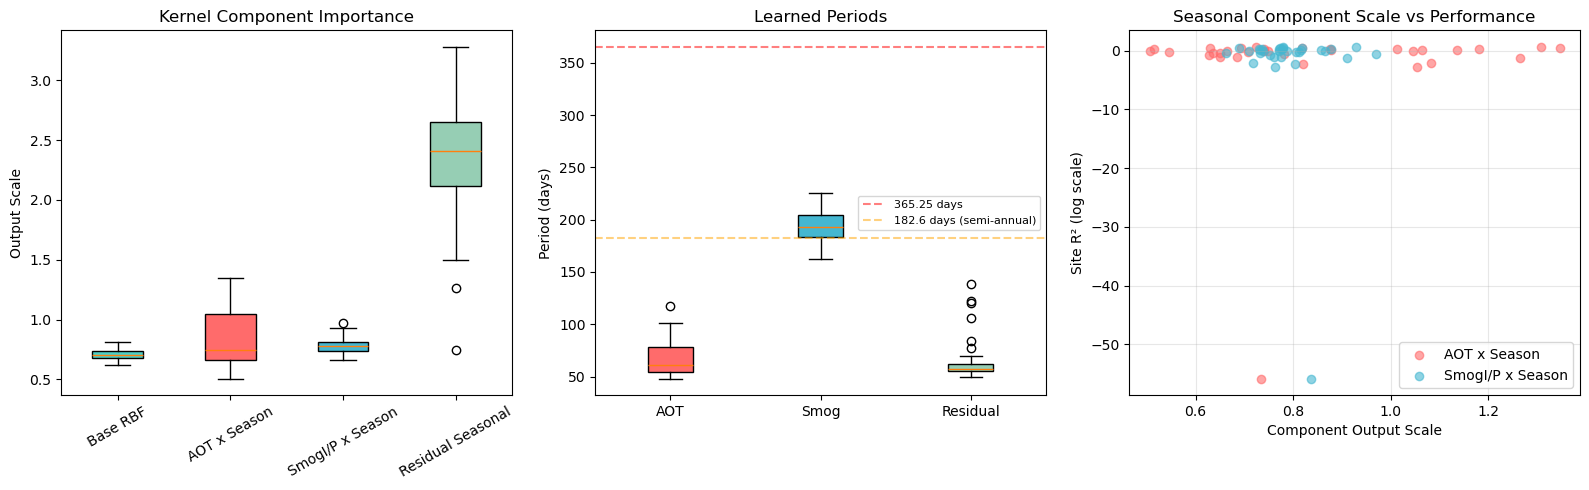

In [14]:
# Visualize kernel component scales across folds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Output scales
scale_cols = ['base_scale', 'summer_scale', 'winter_scale', 'seasonal_scale']
scale_labels = ['Base RBF', 'AOT x Season', 'SmogI/P x Season', 'Residual Seasonal']
scale_data = [params_df[c].values for c in scale_cols]
bp = axes[0].boxplot(scale_data, labels=scale_labels, patch_artist=True)
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Output Scale')
axes[0].set_title('Kernel Component Importance')
axes[0].tick_params(axis='x', rotation=30)

# Learned periods
period_cols = ['aot_period_days', 'smog_period_days', 'residual_period_days']
period_labels = ['AOT', 'Smog', 'Residual']
period_data = [params_df[c].values for c in period_cols]
bp2 = axes[1].boxplot(period_data, labels=period_labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#FF6B6B', '#45B7D1', '#96CEB4']):
    patch.set_facecolor(color)
axes[1].axhline(y=365.25, color='r', linestyle='--', alpha=0.5, label='365.25 days')
axes[1].axhline(y=182.6, color='orange', linestyle='--', alpha=0.5, label='182.6 days (semi-annual)')
axes[1].set_ylabel('Period (days)')
axes[1].set_title('Learned Periods')
axes[1].legend(fontsize=8)

# Component scale vs site R2
merged = params_df.merge(metrics_df, on='site')
for col, label, color in zip(['summer_scale', 'winter_scale'],
                              ['AOT x Season', 'SmogI/P x Season'],
                              ['#FF6B6B', '#45B7D1']):
    axes[2].scatter(merged[col], merged['r2_log'], alpha=0.6, label=label, color=color)
axes[2].set_xlabel('Component Output Scale')
axes[2].set_ylabel('Site R\u00b2 (log scale)')
axes[2].set_title('Seasonal Component Scale vs Performance')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualizations

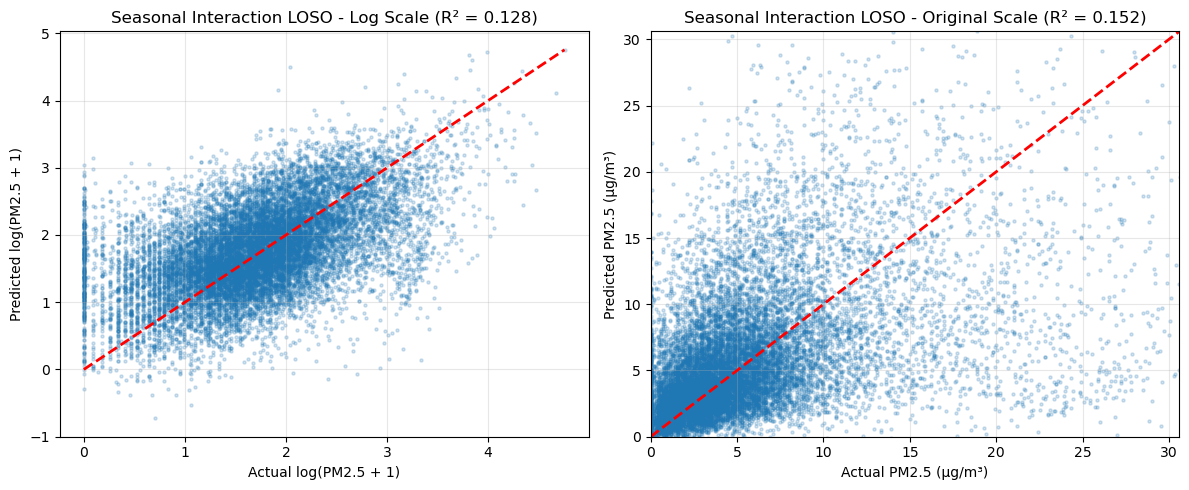

In [15]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actuals, all_predictions, alpha=0.2, s=5)
axes[0].plot([all_actuals.min(), all_actuals.max()],
             [all_actuals.min(), all_actuals.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Seasonal Interaction LOSO - Log Scale (R\u00b2 = {r2_log:.3f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(actual_pm25, pred_pm25, alpha=0.2, s=5)
max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (\u03bcg/m\u00b3)')
axes[1].set_ylabel('Predicted PM2.5 (\u03bcg/m\u00b3)')
axes[1].set_title(f'Seasonal Interaction LOSO - Original Scale (R\u00b2 = {r2_orig:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

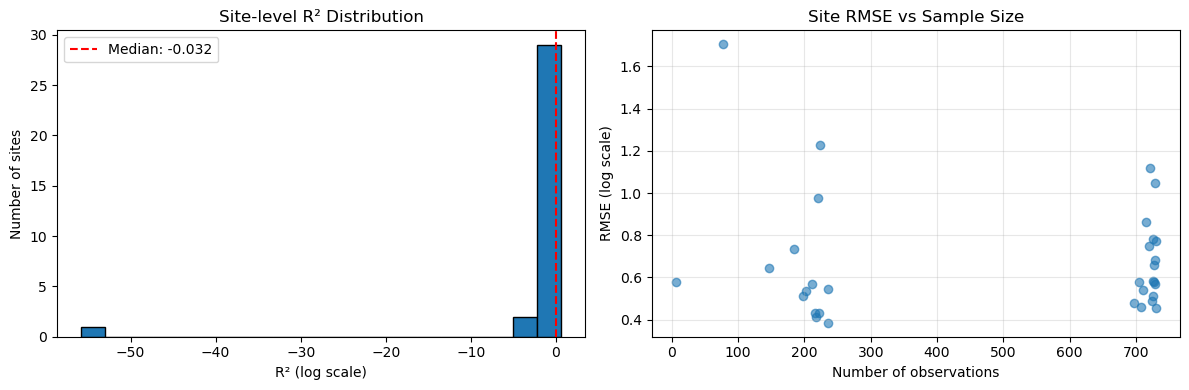

In [16]:
# Site-level R2 distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid_r2 = metrics_df['r2_log'].dropna()
axes[0].hist(valid_r2, bins=20, edgecolor='black')
axes[0].axvline(x=valid_r2.median(), color='r', linestyle='--',
                label=f'Median: {valid_r2.median():.3f}')
axes[0].set_xlabel('R\u00b2 (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Site-level R\u00b2 Distribution')
axes[0].legend()

axes[1].scatter(metrics_df['n_obs'], metrics_df['rmse_log'], alpha=0.6)
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Best and worst performing sites
print("Top 5 best-performing sites (highest R\u00b2):")
print(metrics_df.nlargest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

print("\nTop 5 worst-performing sites (lowest R\u00b2):")
print(metrics_df.nsmallest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

Top 5 best-performing sites (highest R²):
        site  n_obs  rmse_log   r2_log
115672_47955    218  0.412563 0.627547
114001_45860    236  0.384880 0.625282
112013_46659    730  0.455514 0.495015
108720_47582    222  0.430170 0.462011
104476_48487    216  0.429676 0.418123

Top 5 worst-performing sites (lowest R²):
        site  n_obs  rmse_log     r2_log
115195_48971     78  1.704901 -55.823634
109677_48551    203  0.536930  -2.762475
113155_47122    223  1.226002  -2.344065
112364_48607    185  0.732871  -2.118656
113997_48510    221  0.974323  -1.222621


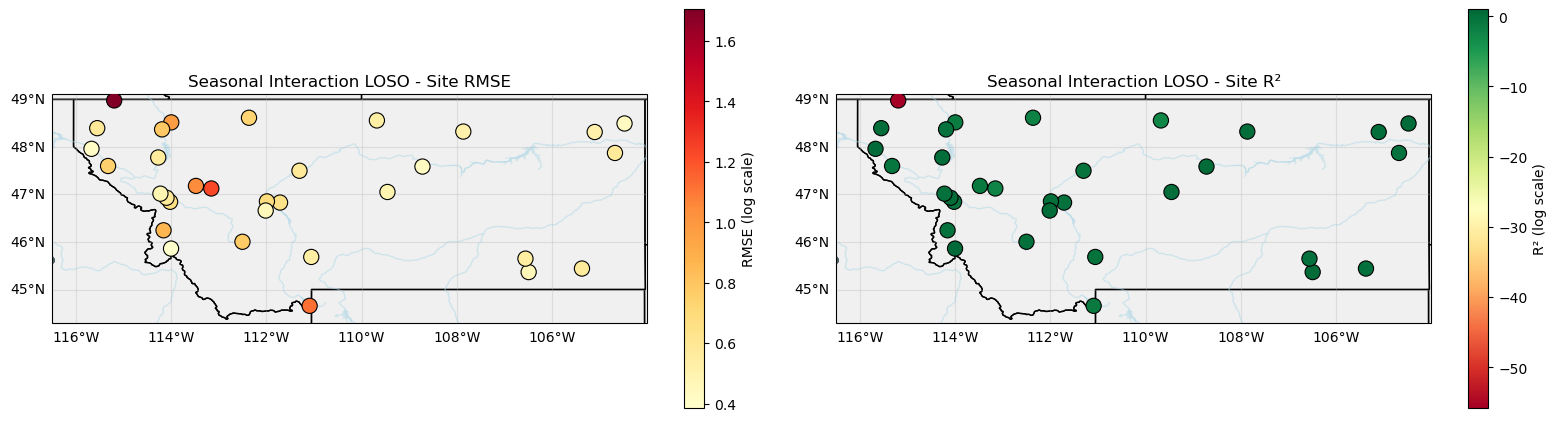

In [18]:
# Map of site-level R2
site_coords = df_clean.groupby('ll_id')[['lat', 'lon']].first().reset_index()
site_with_error = site_coords.merge(metrics_df[['site', 'rmse_log', 'r2_log']],
                                     left_on='ll_id', right_on='site', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax in axes:
    ax.set_extent([-116.5, -104.0, 44.3, 49.1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.0)
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue', alpha=0.5)
    ax.add_feature(cfeature.RIVERS, edgecolor='lightblue', alpha=0.5)

sc1 = axes[0].scatter(site_with_error['lon'], site_with_error['lat'],
                       c=site_with_error['rmse_log'], cmap='YlOrRd',
                       s=120, edgecolors='black', linewidth=0.8,
                       transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc1, ax=axes[0], label='RMSE (log scale)', shrink=0.7)
axes[0].set_title('Seasonal Interaction LOSO - Site RMSE')
gl0 = axes[0].gridlines(draw_labels=True, alpha=0.3)
gl0.top_labels = False
gl0.right_labels = False

r2_min = min(0, site_with_error['r2_log'].min())
sc2 = axes[1].scatter(site_with_error['lon'], site_with_error['lat'],
                       c=site_with_error['r2_log'], cmap='RdYlGn',
                       s=120, edgecolors='black', linewidth=0.8,
                       vmin=r2_min, vmax=1,
                       transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc2, ax=axes[1], label='R\u00b2 (log scale)', shrink=0.7)
axes[1].set_title('Seasonal Interaction LOSO - Site R\u00b2')
gl1 = axes[1].gridlines(draw_labels=True, alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

plt.tight_layout()
plt.show()

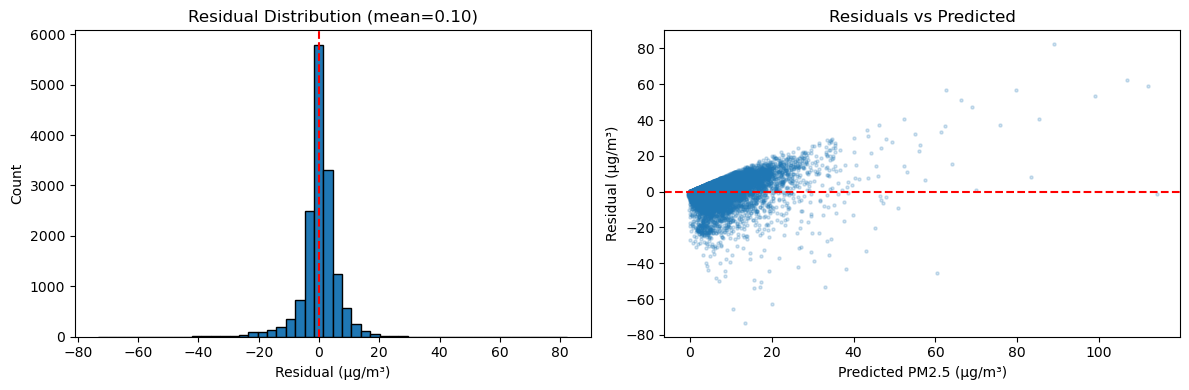

In [19]:
# Residual analysis
residuals = pred_pm25 - actual_pm25

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Residual (\u03bcg/m\u00b3)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residual Distribution (mean={residuals.mean():.2f})')

axes[1].scatter(pred_pm25, residuals, alpha=0.2, s=5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (\u03bcg/m\u00b3)')
axes[1].set_ylabel('Residual (\u03bcg/m\u00b3)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

## 7. Save Results

In [20]:
import os

# Save site-level metrics
metrics_df['years'] = '2018-2019'
metrics_df['model'] = 'seasonal_interaction'
if os.path.exists('../../results/loso_site_metrics.csv'):
    existing = pd.read_csv('../../results/loso_site_metrics.csv')
    pd.concat([existing, metrics_df], ignore_index=True).to_csv('../../results/loso_site_metrics.csv', index=False)
else:
    metrics_df.to_csv('../../results/loso_site_metrics.csv', index=False)
print("Site metrics saved")

# Save overall results
results = {
    'years': '2018-2019',
    'cv_method': 'LOSO',
    'model': 'seasonal_interaction',
    'n_sites': n_sites,
    'n_predictions': len(all_predictions),
    'rmse_log': rmse_log,
    'mae_log': mae_log,
    'r2_log': r2_log,
    'rmse_orig': rmse_orig,
    'mae_orig': mae_orig,
    'r2_orig': r2_orig,
    'total_time_seconds': cv_total_time
}
new_row = pd.DataFrame([results])
if os.path.exists('../../results/loso_overall_results.csv'):
    existing = pd.read_csv('../../results/loso_overall_results.csv')
    pd.concat([existing, new_row], ignore_index=True).to_csv('../../results/loso_overall_results.csv', index=False)
else:
    new_row.to_csv('../../results/loso_overall_results.csv', index=False)
print("Overall results saved")

# Save fold timings
timing_df = pd.DataFrame(fold_timings)
timing_df['years'] = '2018-2019'
timing_df['model'] = 'seasonal_interaction'
if os.path.exists('../../timings/loso_fold_timings.csv'):
    existing = pd.read_csv('../../timings/loso_fold_timings.csv')
    pd.concat([existing, timing_df], ignore_index=True).to_csv('../../timings/loso_fold_timings.csv', index=False)
else:
    timing_df.to_csv('../../timings/loso_fold_timings.csv', index=False)
print("Fold timings saved")

# Save learned kernel parameters
params_df.to_csv('learned_kernel_params.csv', index=False)
print("Kernel parameters saved to learned_kernel_params.csv")

# Timing summary
print(f"\n{'='*50}")
print("Timing Summary")
print(f"{'='*50}")
print(f"Total CV time: {cv_total_time:.1f}s ({cv_total_time/60:.1f} min)")
print(f"\nPer-fold timing (across {len(timing_df)} folds):")
print(f"  Training:  mean={timing_df['train_time'].mean():.2f}s, std={timing_df['train_time'].std():.2f}s")
print(f"  Inference: mean={timing_df['infer_time'].mean():.3f}s, std={timing_df['infer_time'].std():.3f}s")
print(f"  Total:     mean={timing_df['fold_time'].mean():.2f}s, std={timing_df['fold_time'].std():.2f}s")

Site metrics saved
Overall results saved
Fold timings saved
Kernel parameters saved to learned_kernel_params.csv

Timing Summary
Total CV time: 535.8s (8.9 min)

Per-fold timing (across 32 folds):
  Training:  mean=15.82s, std=0.22s
  Inference: mean=0.831s, std=0.036s
  Total:     mean=16.66s, std=0.28s


## Summary

This notebook encodes the hypothesis that PM2.5 in Montana is driven by
**different mechanisms in different seasons**:

- **Summer:** Wildfire smoke captured by AOT
- **Winter:** Cold air drainage inversions captured by smogI and smogP

The kernel structure uses product kernels (feature x season) to let the GP
learn when each feature's influence is active. The learned output scales
reveal the relative importance of each component, and the learned periods
indicate whether the kernel finds meaningful annual cycles.

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season`